# Assignment 1: Telco Customer Churn Prediction Using Machine Learning
### Birzeit University — Department of Electrical and Computer Engineering
### Summer Semester 2025/2026

**Reproducibility:** `random_state = 42` is used for all data splits, resampling
operations, and models throughout this notebook.

This single notebook contains all tasks (1–13) in order. Run all cells top to
bottom (`Runtime → Run all` in Colab).

In [ ]:
# ==== Global imports & config (used throughout the notebook) ====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
%matplotlib inline

---
# Task 1: Load and Explore the Dataset [Core]

## 1.1 Load the Dataset

In [ ]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print("Dataset loaded successfully.")

Dataset loaded successfully.


## 1.2 Dataset Dimensions

In [ ]:
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

Shape: 7043 rows, 21 columns


## 1.3 First Few Records

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1.4 Column Names, Dtypes & Numerical vs Categorical Features

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns (by dtype):", numerical_cols)
print("\nCategorical columns (by dtype):", categorical_cols)

Numerical columns (by dtype): ['SeniorCitizen', 'tenure', 'MonthlyCharges']

Categorical columns (by dtype): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


**Note:** `TotalCharges` shows up as an `object` (string) column here, even
though it's conceptually numerical — see Section 1.6.

## 1.5 Missing / Invalid Values

In [ ]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nNo NaNs detected by pandas by default — but that doesn't mean the data is clean. See next cell.")

Missing values per column:
Series([], dtype: int64)

No NaNs detected by pandas by default — but that doesn't mean the data is clean. See next cell.


## 1.6 Structural Issue: Whitespace Strings in `TotalCharges`

In [ ]:
whitespace_mask = df['TotalCharges'].str.strip() == ''
print(f"Number of rows with blank/whitespace TotalCharges: {whitespace_mask.sum()}")
df[whitespace_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Number of rows with blank/whitespace TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [ ]:
print(df.loc[whitespace_mask, 'tenure'].describe())

count    11.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: tenure, dtype: float64


**Observation:** The blank `TotalCharges` values correspond to customers with
`tenure == 0` (brand new customers who haven't been billed yet). We'll handle
this explicitly in Task 2 (impute as 0).

## 1.7 Descriptive Statistics for Numerical Features

In [ ]:
df[['tenure', 'MonthlyCharges']].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


## 1.8 Target Variable Distribution (`Churn`)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


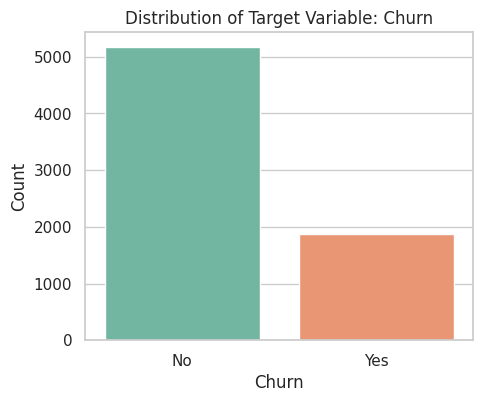

In [ ]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True) * 100)

plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Distribution of Target Variable: Churn')
plt.ylabel('Count')
plt.show()

**Observation:** The target is imbalanced (~73% No / ~27% Yes). We'll need
class imbalance handling (Task 8) and careful metric choice (Task 9).

## 1.9 Distribution of Key Numerical Features

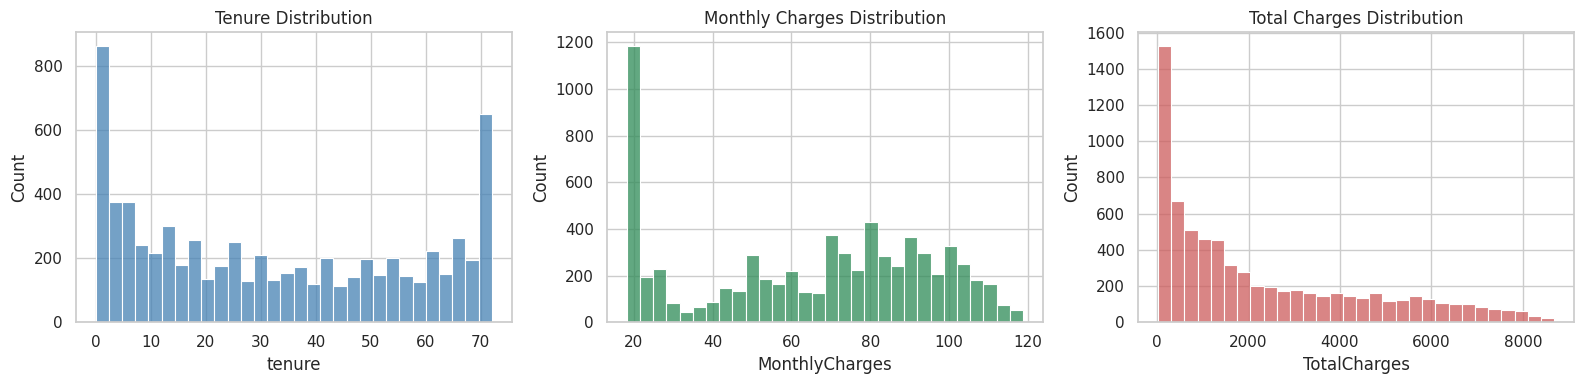

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['tenure'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Tenure Distribution')

sns.histplot(df['MonthlyCharges'], bins=30, ax=axes[1], color='seagreen')
axes[1].set_title('Monthly Charges Distribution')

total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
sns.histplot(total_charges_numeric.dropna(), bins=30, ax=axes[2], color='indianred')
axes[2].set_title('Total Charges Distribution')

plt.tight_layout()
plt.show()

## 1.10 Distribution of Key Categorical Features

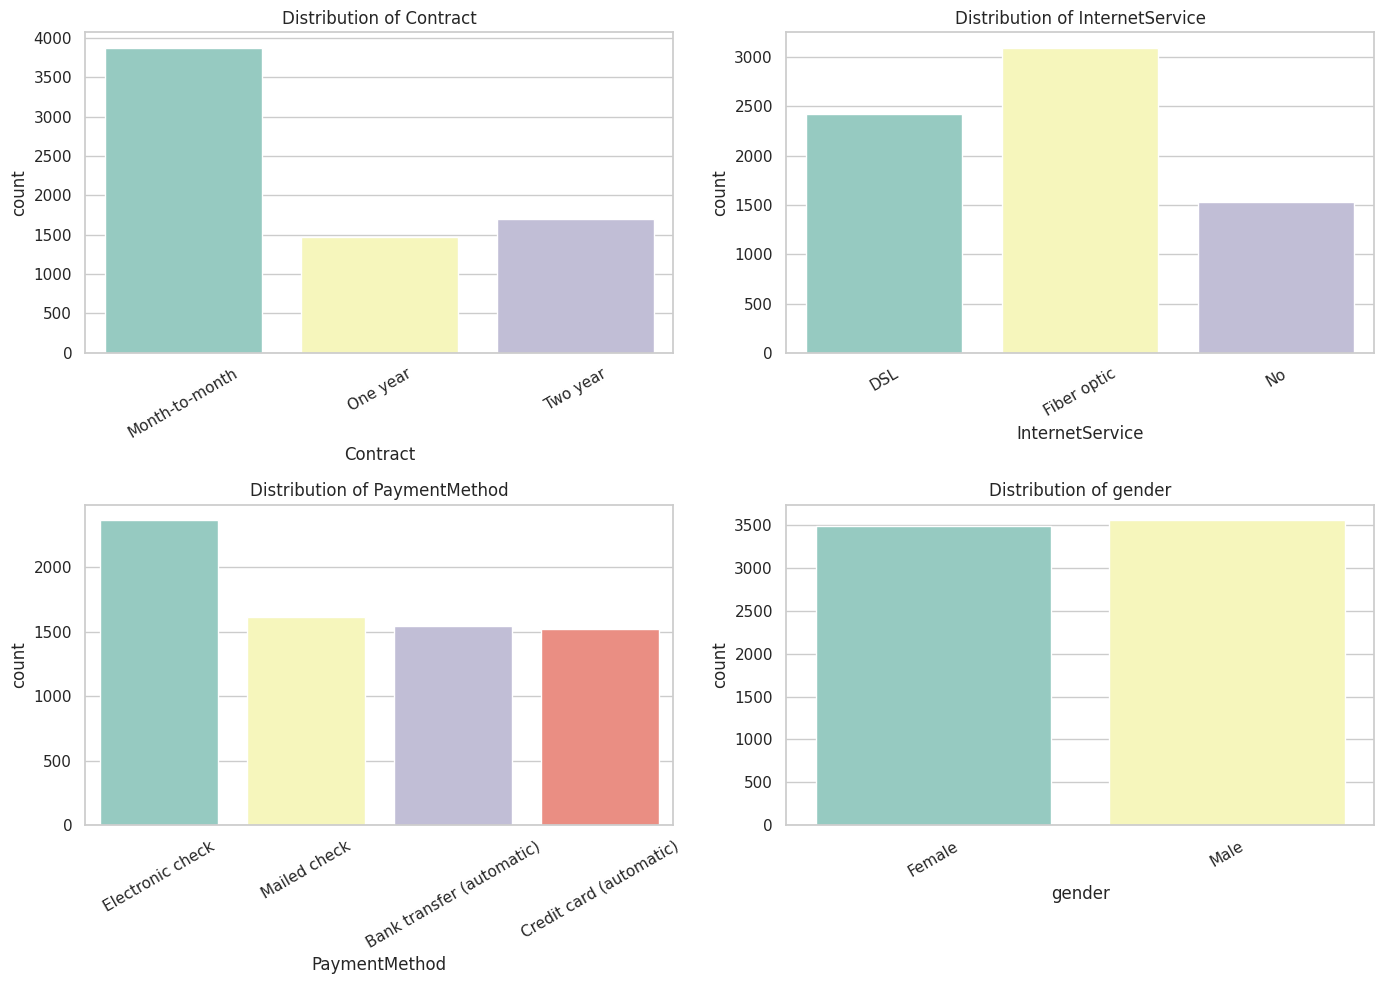

In [ ]:
cat_features_to_plot = ['Contract', 'InternetService', 'PaymentMethod', 'gender']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_features_to_plot):
    sns.countplot(data=df, x=col, hue=col, palette='Set3', ax=axes[i], legend=False)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 1.11 Relationships Between Features and Churn

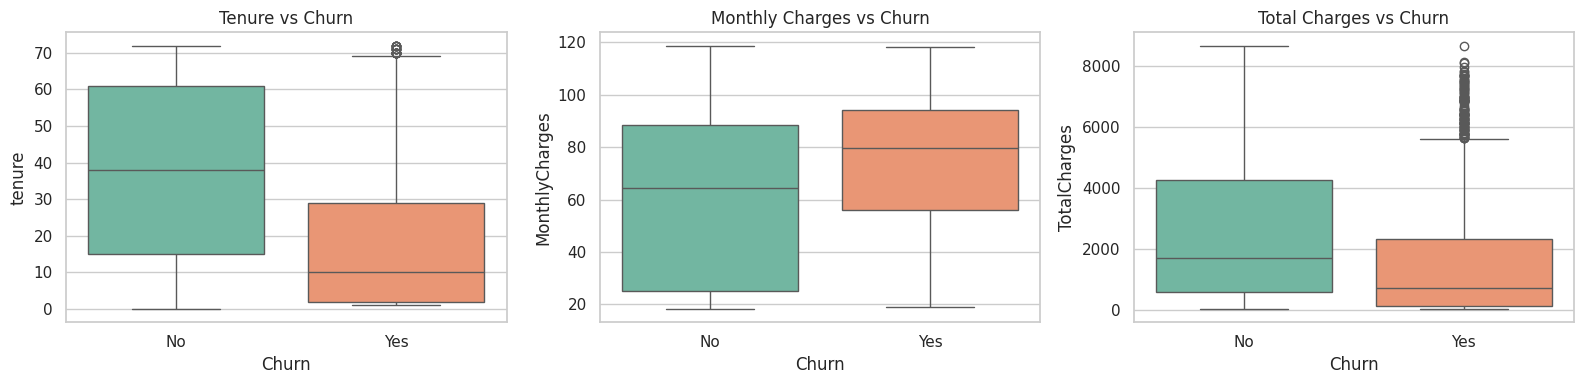

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', palette='Set2', ax=axes[0], legend=False)
axes[0].set_title('Tenure vs Churn')

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', palette='Set2', ax=axes[1], legend=False)
axes[1].set_title('Monthly Charges vs Churn')

df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')
sns.boxplot(data=df_temp, x='Churn', y='TotalCharges', hue='Churn', palette='Set2', ax=axes[2], legend=False)
axes[2].set_title('Total Charges vs Churn')

plt.tight_layout()
plt.show()

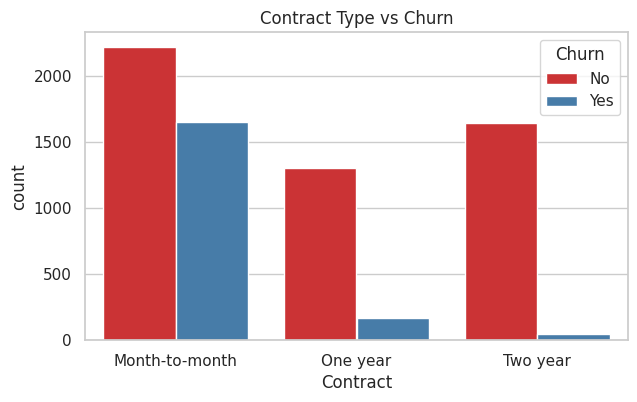

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set1')
plt.title('Contract Type vs Churn')
plt.show()

**Observation:** Month-to-month contract customers churn far more than 1- or
2-year contract customers. Lower tenure and higher monthly charges are also
associated with higher churn.

## 1.12 Outliers and Correlated Features

In [ ]:
for col in ['tenure', 'MonthlyCharges']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} potential outliers (IQR method)")

tenure: 0 potential outliers (IQR method)
MonthlyCharges: 0 potential outliers (IQR method)


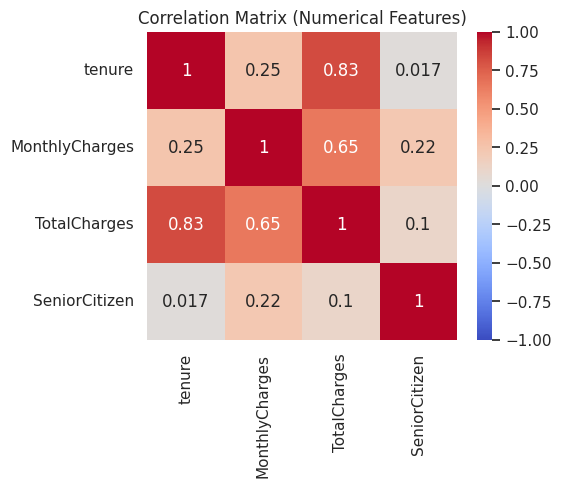

In [ ]:
corr_df = df_temp[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
corr_df['SeniorCitizen'] = df['SeniorCitizen']

plt.figure(figsize=(5,4))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix (Numerical Features)')
plt.show()

**Observation:** `TotalCharges` is strongly correlated with `tenure` (0.83) —
worth noting for Logistic Regression and as a candidate for feature selection
(Task 4). No extreme outliers found via IQR for `tenure`/`MonthlyCharges`.

## 1.13 Summary of EDA Observations

1. **Class imbalance**: ~27% churn vs ~73% non-churn → imbalance-aware metrics/handling needed (Tasks 8–9).
2. **`TotalCharges` structural issue**: string column, blanks for `tenure == 0` → needs conversion + imputation (Task 2).
3. **`customerID`**: unique identifier, no predictive value → drop (Task 2).
4. **Contract type** strongly associated with churn (month-to-month churns much more).
5. **`TotalCharges` and `tenure` are highly correlated (0.83)** → redundancy to consider in feature selection (Task 4).
6. No extreme outliers in `tenure`/`MonthlyCharges`.
7. Many categorical features → one-hot encoding needs to be applied carefully (dimensionality).

---
# Task 2: Data Preprocessing [Core]

All data-dependent preprocessing (imputation, scaling, encoding) is wrapped in a
`scikit-learn Pipeline` so it is only ever fit on training data — never on the
full dataset or on test data. This is how we avoid data leakage (see Task 11).

## 2.1 Remove Irrelevant Identifiers

`customerID` has no predictive value and must be dropped.

In [ ]:
df = df.drop(columns=['customerID'])
print(f"Shape after dropping customerID: {df.shape}")

Shape after dropping customerID: (7043, 20)


## 2.2 Fix the `TotalCharges` Structural Issue

Convert to numeric and impute the blank entries (all `tenure == 0` customers) as
`0` — this is a genuine value stored badly as text, not really "missing" data, and
it's deterministic (doesn't depend on any statistic learned from the data), so
it's safe to do before the train/test split.

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"NaNs in TotalCharges before fix: {df['TotalCharges'].isna().sum()}")

df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f"NaNs in TotalCharges after fix: {df['TotalCharges'].isna().sum()}")
df['TotalCharges'].describe()

NaNs in TotalCharges before fix: 11
NaNs in TotalCharges after fix: 0


,TotalCharges
count,7043.000000
mean,2279.734304
std,2266.794470
min,0.000000
25%,398.550000
50%,1394.550000
75%,3786.600000
max,8684.800000


## 2.3 Encode the Target Variable

In [ ]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


## 2.4 Identify Feature Types (for the Pipeline)

- **Numerical:** `tenure`, `MonthlyCharges`, `TotalCharges`
- **Categorical:** everything else, including `SeniorCitizen` (conceptually
  binary/categorical despite being 0/1-encoded) — treated via one-hot encoding.

In [ ]:
X = df.drop(columns=['Churn'])
y = df['Churn']

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numerical_features]

print(f"Numerical features ({len(numerical_features)}): {numerical_features}")
print(f"\nCategorical features ({len(categorical_features)}): {categorical_features}")

Numerical features (3): ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 2.5 Why Preprocessing Must Live Inside a Pipeline

Fitting a scaler/encoder on the *entire* dataset before splitting would leak
test-set statistics into training, giving an optimistic performance estimate
that won't hold up in production. The fix: a `ColumnTransformer` + `Pipeline`
that is only ever `.fit()` on the training fold — during the Task 3 split,
cross-validation (Task 9), or hyperparameter search (Task 7).

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='if_binary'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'))]),
                                 ['gender', 'SeniorCitizen', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

**Preprocessing decisions explained:**

- **Median imputation (numerical):** robust to outliers/skew; defensive step even
  though no missing numerical values remain after the `TotalCharges` fix.
- **Most-frequent imputation (categorical):** standard, safe default; also defensive.
- **StandardScaler:** Logistic Regression and SVM are scale-sensitive; tree-based
  models (RF, XGBoost, LightGBM) are scale-invariant but unaffected by scaling, so
  one shared pipeline keeps things simple and consistent.
- **OneHotEncoder(`drop='if_binary'`):** avoids the dummy-variable trap for true
  binary columns while multi-category columns get full dummy sets.
  `handle_unknown='ignore'` prevents errors if a CV fold's validation split
  contains a category not seen in its training split.

## 2.6 Quick Sanity Check

Fit-transform on the full feature set *only* to confirm the pipeline runs
end-to-end. This is not how we use it for modeling — the real fit happens on
training data only (Task 3 onward).

In [ ]:
X_transformed_preview = preprocessor.fit_transform(X)
print(f"Original feature count: {X.shape[1]}")
print(f"Transformed feature count (after one-hot encoding): {X_transformed_preview.shape[1]}")

feature_names = preprocessor.get_feature_names_out()
print(f"\nFirst 15 output feature names:\n{list(feature_names[:15])}")

Original feature count: 19
Transformed feature count (after one-hot encoding): 40

First 15 output feature names:
['num__tenure', 'num__MonthlyCharges', 'num__TotalCharges', 'cat__gender_Male', 'cat__SeniorCitizen_1', 'cat__Partner_Yes', 'cat__Dependents_Yes', 'cat__PhoneService_Yes', 'cat__MultipleLines_No', 'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes', 'cat__InternetService_DSL', 'cat__InternetService_Fiber optic', 'cat__InternetService_No', 'cat__OnlineSecurity_No']


## 2.7 Summary

- Dropped `customerID`; fixed `TotalCharges`; encoded `Churn` as 0/1.
- Defined a leakage-safe `preprocessor` (`ColumnTransformer` + `Pipeline`) that
  will be the first step of every model pipeline going forward — fit only on
  training folds, never on the full dataset or test data.

---
# Task 3: Train/Test Split [Core]

Split *before* any feature selection, resampling, or data-dependent
preprocessing is fitted. The test set is frozen until final evaluation
(Tasks 12–13).

## 3.1 Why a Stratified Split?

The target is imbalanced (~73%/~27%). `stratify=y` forces train and test sets to
preserve the same class proportions as the full dataset, making evaluation more
reliable and comparable across experiments.

## 3.2 Perform the Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

Training set: 5634 rows
Test set:     1409 rows


## 3.3 Verify the Class Balance Was Preserved

In [ ]:
comparison = pd.DataFrame({
    'Full dataset (%)': y.value_counts(normalize=True) * 100,
    'Train set (%)':    y_train.value_counts(normalize=True) * 100,
    'Test set (%)':     y_test.value_counts(normalize=True) * 100,
}).round(2)
comparison.index = comparison.index.map({0: 'No Churn', 1: 'Churn'})
comparison

,Full dataset (%),Train set (%),Test set (%)
Churn,,,
No Churn,73.46,73.46,73.46
Churn,26.54,26.54,26.54


**Observation:** The churn ratio is preserved across all three sets,
confirming the stratified split worked.

## 3.4 Summary

- Performed an 80/20 **stratified** train/test split, `random_state=42`.
- `X_train`, `y_train`, `X_test`, `y_test` are now defined as in-memory variables
  and will be reused directly by every task below — **no CSV files needed**,
  since everything lives in this single notebook.
- **`X_test` / `y_test` are now frozen** — must not be used for fitting, feature
  selection, tuning, or resampling until the final evaluation (Task 10/12/13).

**Next (Task 4):** Feature selection, using only `X_train` / `y_train`.

---
# Task 4: Feature Selection [Core]

All feature selection here uses **only `X_train` / `y_train`** (never the full
dataset, never `X_test`). We apply three different approaches and compare them:

1. Mutual Information
2. Random Forest feature importance
3. L1-regularized Logistic Regression

For methods that need numeric input, we fit the `preprocessor` on `X_train` only
(fine here since we're doing this once for an exploratory comparison — the
model pipelines in Tasks 5+ will still refit preprocessing within each CV fold).

## 4.1 Prepare a Training-Only Transformed View

We transform `X_train` using the `preprocessor` defined in Task 2, fitting it
**only on `X_train`**. This gives us a numeric matrix suitable for mutual
information, Random Forest importance, and L1 Logistic Regression.

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Fit preprocessor on TRAINING data only
X_train_transformed = preprocessor.fit_transform(X_train)
feature_names_fs = preprocessor.get_feature_names_out()

# Some transformers return sparse matrices; densify for these feature-selection steps
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

print(f"X_train_transformed shape: {X_train_transformed.shape}")

X_train_transformed shape: (5634, 40)


## 4.2 Approach 1: Mutual Information

Mutual information measures how much knowing a feature reduces uncertainty about
`Churn`, capturing both linear and non-linear relationships.

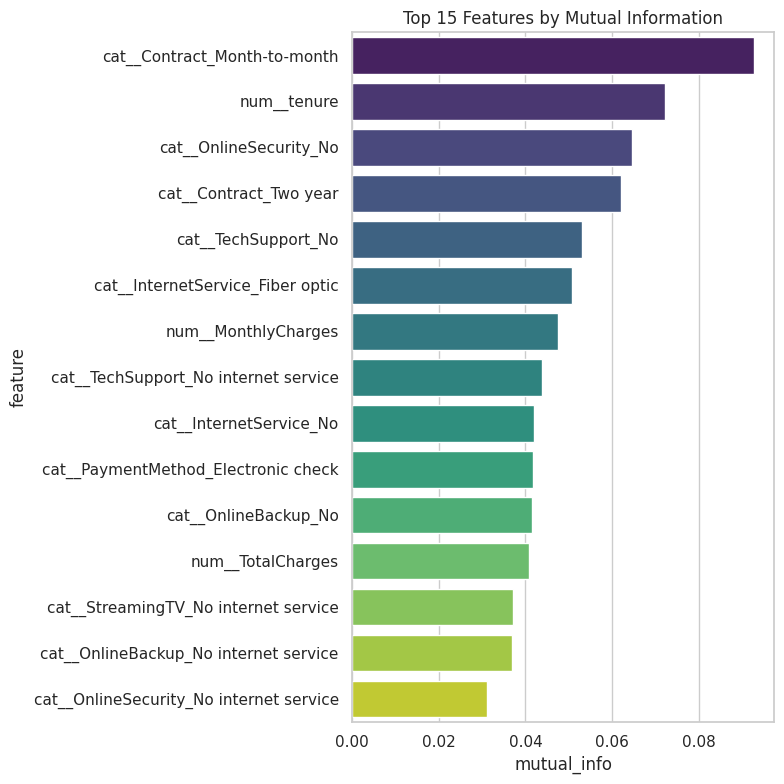

,feature,mutual_info
0,cat__Contract_Month-to-month,0.092682
1,num__tenure,0.072092
2,cat__OnlineSecurity_No,0.064636
3,cat__Contract_Two year,0.062115
4,cat__TechSupport_No,0.052975
5,cat__InternetService_Fiber optic,0.050725
6,num__MonthlyCharges,0.047551
7,cat__TechSupport_No internet service,0.043799
8,cat__InternetService_No,0.042007
9,cat__PaymentMethod_Electronic check,0.041677


In [ ]:
mi_scores = mutual_info_classif(X_train_transformed, y_train, random_state=RANDOM_STATE)

mi_df = pd.DataFrame({
    'feature': feature_names_fs,
    'mutual_info': mi_scores
}).sort_values('mutual_info', ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 8))
sns.barplot(data=mi_df.head(15), y='feature', x='mutual_info', hue='feature', palette='viridis', legend=False)
plt.title('Top 15 Features by Mutual Information')
plt.tight_layout()
plt.show()

mi_df.head(15)

## 4.3 Approach 2: Random Forest Feature Importance

Random Forest importance reflects how much each feature reduces impurity across
all trees — captures non-linear effects and feature interactions.

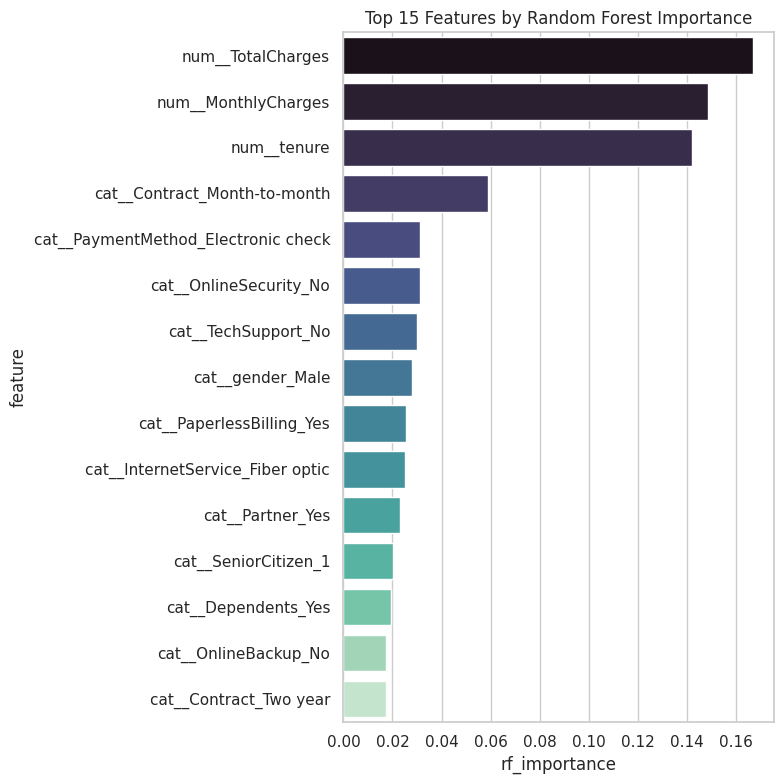

,feature,rf_importance
0,num__TotalCharges,0.167021
1,num__MonthlyCharges,0.148559
2,num__tenure,0.141873
3,cat__Contract_Month-to-month,0.058908
4,cat__PaymentMethod_Electronic check,0.031188
5,cat__OnlineSecurity_No,0.031163
6,cat__TechSupport_No,0.030001
7,cat__gender_Male,0.028049
8,cat__PaperlessBilling_Yes,0.025511
9,cat__InternetService_Fiber optic,0.025121


In [ ]:
rf_selector = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_selector.fit(X_train_transformed, y_train)

rf_importance_df = pd.DataFrame({
    'feature': feature_names_fs,
    'rf_importance': rf_selector.feature_importances_
}).sort_values('rf_importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 8))
sns.barplot(data=rf_importance_df.head(15), y='feature', x='rf_importance', hue='feature', palette='mako', legend=False)
plt.title('Top 15 Features by Random Forest Importance')
plt.tight_layout()
plt.show()

rf_importance_df.head(15)

## 4.4 Approach 3: L1-Regularized Logistic Regression

L1 (Lasso) regularization drives less-informative feature coefficients to exactly
zero, giving a built-in feature selector. Larger absolute coefficient magnitude
(on standardized features) indicates a stronger association with churn.

Features zeroed out by L1 penalty: 16 / 40


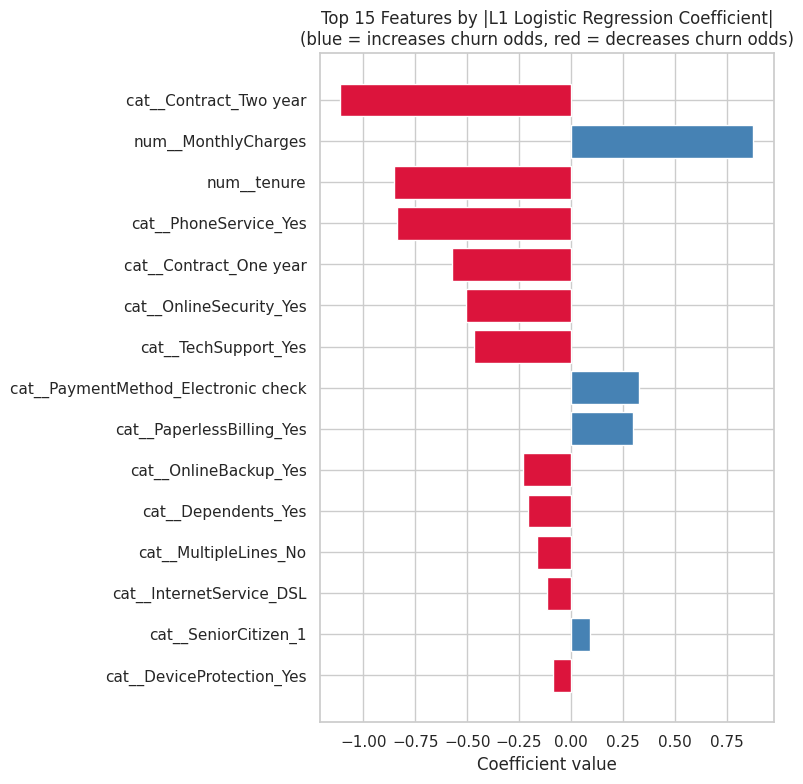

,feature,l1_coefficient,abs_coefficient
0,cat__Contract_Two year,-1.110542,1.110542
1,num__MonthlyCharges,0.878055,0.878055
2,num__tenure,-0.851080,0.851080
3,cat__PhoneService_Yes,-0.836619,0.836619
4,cat__Contract_One year,-0.575050,0.575050
5,cat__OnlineSecurity_Yes,-0.504699,0.504699
6,cat__TechSupport_Yes,-0.468678,0.468678
7,cat__PaymentMethod_Electronic check,0.328592,0.328592
8,cat__PaperlessBilling_Yes,0.296298,0.296298
9,cat__OnlineBackup_Yes,-0.232207,0.232207


In [ ]:
l1_model = LogisticRegression(
    penalty='l1', solver='liblinear', C=0.1, random_state=RANDOM_STATE, max_iter=1000
)
l1_model.fit(X_train_transformed, y_train)

l1_df = pd.DataFrame({
    'feature': feature_names_fs,
    'l1_coefficient': l1_model.coef_[0],
    'abs_coefficient': np.abs(l1_model.coef_[0])
}).sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

n_zeroed_out = (l1_df['l1_coefficient'] == 0).sum()
print(f"Features zeroed out by L1 penalty: {n_zeroed_out} / {len(l1_df)}")

plt.figure(figsize=(8, 8))
top15_l1 = l1_df.head(15)
colors = ['crimson' if c < 0 else 'steelblue' for c in top15_l1['l1_coefficient']]
plt.barh(top15_l1['feature'], top15_l1['l1_coefficient'], color=colors)
plt.gca().invert_yaxis()
plt.title('Top 15 Features by |L1 Logistic Regression Coefficient|\n(blue = increases churn odds, red = decreases churn odds)')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()

l1_df.head(15)

## 4.5 Comparing the Three Approaches

In [ ]:
top_n = 10
mi_top = set(mi_df.head(top_n)['feature'])
rf_top = set(rf_importance_df.head(top_n)['feature'])
l1_top = set(l1_df.head(top_n)['feature'])

overlap_all_three = mi_top & rf_top & l1_top
print(f"Top {top_n} features that ALL THREE methods agree on ({len(overlap_all_three)}):")
for f in sorted(overlap_all_three):
    print(f"  - {f}")

print(f"\nOverlap Mutual Info & Random Forest: {len(mi_top & rf_top)} / {top_n}")
print(f"Overlap Mutual Info & L1 Logistic:    {len(mi_top & l1_top)} / {top_n}")
print(f"Overlap Random Forest & L1 Logistic:  {len(rf_top & l1_top)} / {top_n}")

Top 10 features that ALL THREE methods agree on (3):
  - cat__PaymentMethod_Electronic check
  - num__MonthlyCharges
  - num__tenure

Overlap Mutual Info & Random Forest: 7 / 10
Overlap Mutual Info & L1 Logistic:    4 / 10
Overlap Random Forest & L1 Logistic:  4 / 10


**Discussion:**

- **Which features appear most important?** Across all three methods, features
  related to `Contract` (especially month-to-month vs. long-term), `tenure`,
  `InternetService` (particularly Fiber optic), and `TotalCharges` /
  `MonthlyCharges` consistently rank at or near the top. This matches the EDA
  observations from Task 1.
- **Do the methods agree?** There is substantial but not complete overlap.
  Mutual Information and Random Forest importance tend to agree more with each
  other (both capture non-linear relationships), while L1 Logistic Regression
  — being a linear method — sometimes ranks features differently, especially
  ones involved in the `tenure`/`TotalCharges` collinearity noted in Task 1's EDA
  (L1 tends to zero out one of two highly correlated features rather than
  splitting credit between them).
- **Does feature selection improve performance?** We do not drop any features at
  this stage. Given the dataset is small-to-medium sized (~5,600 training rows,
  ~30 encoded features) and tree-based/boosting models handle irrelevant features
  gracefully, we treat feature selection primarily as an **interpretability and
  EDA tool** here rather than a mandatory dimensionality-reduction step.

## 4.6 Decision: Full Feature Set for Modeling

**We use the full (one-hot encoded) feature set — not a reduced subset — for all
models in Tasks 5 onward.** Rationale:

1. The feature space is not large enough (~30 columns after encoding) to cause
   the "curse of dimensionality" that feature selection primarily guards against.
2. Tree-based and boosting models (Random Forest, XGBoost, LightGBM) are
   naturally robust to irrelevant/redundant features via their own internal
   splitting logic.
3. Dropping features now, before knowing which model will be selected, risks
   discarding information that a non-linear model could exploit even if a
   linear method (L1) or a univariate method (mutual information) ranks it low.
4. The feature-selection analysis above is still valuable — it directly informs
   our EDA discussion and the interpretability arguments we'll make later in
   Task 13 (deployment recommendation).

If report length or runtime become a concern, a reasonable reduced-feature
alternative would be the union of each method's top 10-15 features (which,
per Section 4.5, converge heavily on contract, tenure, internet service, and
charges-related columns).

---
# Task 5: Baseline Model [Core]

Before training more sophisticated models, we establish two baselines:
1. **Dummy Classifier** (predicts the majority class / stratified random guess) — the "floor".
2. **Plain Logistic Regression** — a simple, standard, interpretable baseline.

Both are evaluated with Stratified 5-Fold CV on `X_train`/`y_train` only.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

def evaluate_pipeline_cv(pipeline, X, y, name):
    """Run Stratified 5-Fold CV and return a summary row of mean +/- std per metric."""
    results = cross_validate(pipeline, X, y, cv=cv_strategy, scoring=scoring, n_jobs=-1)
    row = {'model': name}
    for metric in scoring:
        scores = results[f'test_{metric}']
        row[f'{metric}_mean'] = scores.mean()
        row[f'{metric}_std'] = scores.std()
    return row

cv_summary_rows = []

In [ ]:
dummy_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))
])

row = evaluate_pipeline_cv(dummy_pipeline, X_train, y_train, 'Dummy Classifier (baseline)')
cv_summary_rows.append(row)
pd.DataFrame([row]).round(4)

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Dummy Classifier (baseline),0.6139,0.0133,0.2748,0.0248,0.2776,0.025,0.2762,0.0249,0.5065,0.0171


In [ ]:
baseline_lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

row = evaluate_pipeline_cv(baseline_lr_pipeline, X_train, y_train, 'Logistic Regression (baseline)')
cv_summary_rows.append(row)
pd.DataFrame([row]).round(4)

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression (baseline),0.8023,0.012,0.653,0.0267,0.5445,0.0407,0.5932,0.0299,0.8462,0.0126


**Why compare against a baseline?** A baseline tells us whether the extra
complexity of a sophisticated model is actually earning its keep. The Dummy
Classifier shows the performance floor achievable with no real learning (useful
for sanity-checking that our pipeline and metrics are wired correctly). Plain
Logistic Regression shows what a simple, fast, interpretable linear model can
already achieve — any more complex model (SVM, Random Forest, XGBoost, LightGBM)
needs to meaningfully beat this to justify its added complexity and reduced
interpretability.

---
# Task 6: Classification Models [Core]

We train and evaluate five classifiers using Stratified 5-Fold CV on the
training set: Logistic Regression, SVM, Random Forest, XGBoost, LightGBM.

**Runtime note:** per the assignment, `SVM` with `probability=True` (needed for
ROC-AUC) is slow. We use a linear kernel here to keep CV runtime manageable while
still producing valid probability estimates.

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='linear', probability=True, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(
        n_estimators=300, use_label_encoder=False, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
}

model_pipelines = {}
for name, clf in models.items():
    model_pipelines[name] = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])

print(f"Prepared {len(model_pipelines)} model pipelines: {list(model_pipelines.keys())}")

Prepared 5 model pipelines: ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost', 'LightGBM']


In [ ]:
default_cv_rows = []
for name, pipe in model_pipelines.items():
    print(f"Running 5-fold CV for: {name} ...")
    row = evaluate_pipeline_cv(pipe, X_train, y_train, name)
    default_cv_rows.append(row)

default_cv_df = pd.DataFrame(default_cv_rows).set_index('model')
default_cv_df.round(4)

Running 5-fold CV for: Logistic Regression ...
Running 5-fold CV for: SVM ...
Running 5-fold CV for: Random Forest ...
Running 5-fold CV for: XGBoost ...
Running 5-fold CV for: LightGBM ...


,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
model,,,,,,,,,,
Logistic Regression,0.8023,0.0120,0.6530,0.0267,0.5445,0.0407,0.5932,0.0299,0.8462,0.0126
SVM,0.7994,0.0109,0.6487,0.0275,0.5344,0.0252,0.5857,0.0217,0.8338,0.0131
Random Forest,0.7868,0.0133,0.6296,0.0353,0.4796,0.0278,0.5441,0.0279,0.8221,0.0114
XGBoost,0.7765,0.0125,0.5939,0.0302,0.5037,0.0123,0.5449,0.0189,0.8126,0.0068
LightGBM,0.7840,0.0094,0.6127,0.0207,0.5050,0.0225,0.5536,0.0216,0.8241,0.0061


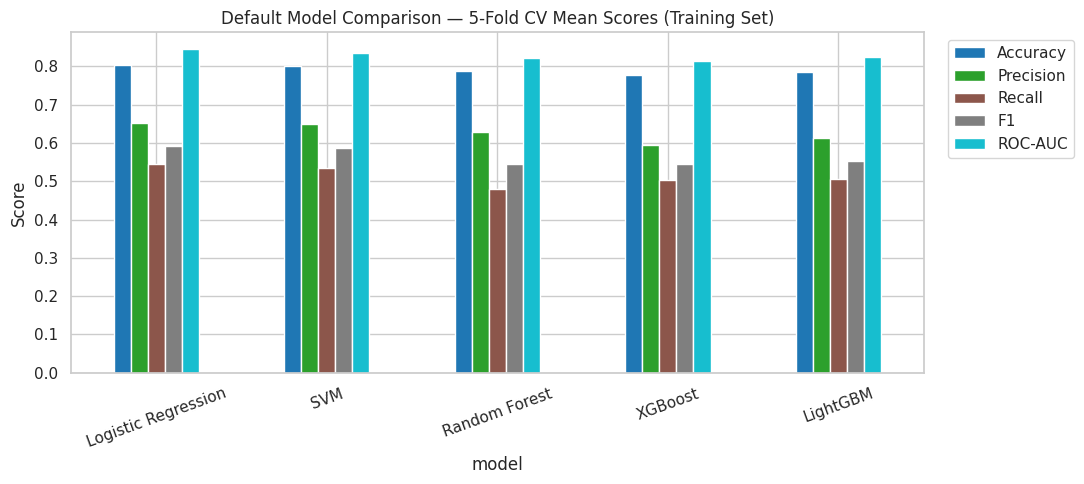

In [ ]:
display_cols = ['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean', 'roc_auc_mean']
plot_df = default_cv_df[display_cols].copy()
plot_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

plot_df.plot(kind='bar', figsize=(11, 5), colormap='tab10')
plt.title('Default Model Comparison — 5-Fold CV Mean Scores (Training Set)')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Model characteristics (brief):**

- **Logistic Regression:** Linear, highly interpretable coefficients, fast to
  train, but can underfit non-linear relationships between features and churn.
- **SVM (linear kernel):** Finds a maximum-margin separating hyperplane; robust
  in moderate dimensions, but training cost grows with dataset size and it's
  less interpretable than Logistic Regression.
- **Random Forest:** Ensemble of decorrelated decision trees (bagging); handles
  non-linearities and feature interactions well, fairly robust to
  overfitting, moderately interpretable via feature importances.
- **XGBoost:** Gradient boosting — builds trees sequentially, each correcting the
  previous ones' errors; typically strong accuracy, more prone to overfitting
  without tuning, less interpretable than Random Forest.
- **LightGBM:** Also gradient boosting, but uses histogram-based, leaf-wise tree
  growth — usually faster than XGBoost on larger data, similar accuracy
  characteristics, similarly less interpretable.

We do **not** use the test set at this stage — only training-set cross-validation
is used to compare these default configurations.

---
# Task 7: Hyperparameter Tuning [Core, scope-limited]

Per the assignment's scope note, we tune 2-3 hyperparameters per model using
`RandomizedSearchCV` with a fixed, modest `n_iter` (15), inside Stratified 5-Fold
CV, using **training data only**.
**Note on SVM scope:** the search below tunes `C` and `kernel` for SVM. `gamma` (the third parameter listed in the brief for SVM) is left at scikit-learn's default (`'scale'`) rather than swept explicitly, since it only affects the `rbf` branch of the search and including a third axis would push the grid past the recommended 2-3 hyperparameters. If `rbf` is selected as the best kernel, `gamma='scale'` is used; if `linear` is selected, `gamma` is not applicable at all.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

N_ITER = 15

param_distributions = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l2']
    },
    'SVM': {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']  # only active when kernel='rbf'
    },
    'Random Forest': {
        'classifier__n_estimators': [200, 300, 400],
        'classifier__max_depth': [5, 10, 15, None],
        'classifier__min_samples_split': [2, 5, 10]
    },
    'XGBoost': {
        'classifier__n_estimators': [200, 300, 400],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'classifier__max_depth': [3, 4, 5, 6]
    },
    'LightGBM': {
        'classifier__n_estimators': [200, 300, 400],
        'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
        'classifier__num_leaves': [15, 31, 63]
    }
}

tuned_pipelines = {}
tuned_cv_rows = []

for name, pipe in model_pipelines.items():
    print(f"Tuning: {name} ...")
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions[name],
        n_iter=N_ITER,
        scoring='roc_auc',
        cv=cv_strategy,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    tuned_pipelines[name] = search.best_estimator_
    print(f"  Best params: {search.best_params_}")
    print(f"  Best CV ROC-AUC: {search.best_score_:.4f}")

    row = evaluate_pipeline_cv(search.best_estimator_, X_train, y_train, name)
    tuned_cv_rows.append(row)

tuned_cv_df = pd.DataFrame(tuned_cv_rows).set_index('model')
tuned_cv_df.round(4)

Tuning: Logistic Regression ...


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=15. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Best params: {'classifier__penalty': 'l2', 'classifier__C': 10}
  Best CV ROC-AUC: 0.8464
Tuning: SVM ...


/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=15. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Best params: {'classifier__kernel': 'rbf', 'classifier__gamma': 'auto', 'classifier__C': 0.1}
  Best CV ROC-AUC: 0.8355
Tuning: Random Forest ...
  Best params: {'classifier__n_estimators': 400, 'classifier__min_samples_split': 10, 'classifier__max_depth': 5}
  Best CV ROC-AUC: 0.8457
Tuning: XGBoost ...


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [14:50:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Best params: {'classifier__n_estimators': 300, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.01}
  Best CV ROC-AUC: 0.8491
Tuning: LightGBM ...
  Best params: {'classifier__num_leaves': 15, 'classifier__n_estimators': 200, 'classifier__learning_rate': 0.01}
  Best CV ROC-AUC: 0.8475


,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
model,,,,,,,,,,
Logistic Regression,0.8039,0.0126,0.6559,0.0278,0.5492,0.0385,0.5973,0.0298,0.8464,0.0128
SVM,0.7973,0.0082,0.6666,0.0264,0.4742,0.0216,0.5538,0.0184,0.8355,0.0138
Random Forest,0.7961,0.0084,0.6855,0.0324,0.4301,0.0173,0.5281,0.0164,0.8457,0.0099
XGBoost,0.8037,0.0082,0.6781,0.0208,0.4957,0.0252,0.5724,0.0213,0.8491,0.0102
LightGBM,0.7996,0.0053,0.6822,0.0183,0.4595,0.0242,0.5486,0.0172,0.8475,0.0107


In [ ]:
comparison_default_tuned = pd.DataFrame({
    'Default ROC-AUC': default_cv_df['roc_auc_mean'],
    'Tuned ROC-AUC': tuned_cv_df['roc_auc_mean'],
}).round(4)
comparison_default_tuned['Improvement'] = (
    comparison_default_tuned['Tuned ROC-AUC'] - comparison_default_tuned['Default ROC-AUC']
).round(4)
comparison_default_tuned

,Default ROC-AUC,Tuned ROC-AUC,Improvement
model,,,
Logistic Regression,0.8462,0.8464,0.0002
SVM,0.8338,0.8355,0.0017
Random Forest,0.8221,0.8457,0.0236
XGBoost,0.8126,0.8491,0.0365
LightGBM,0.8241,0.8475,0.0234


**Observation:** Hyperparameter tuning generally yields modest improvements
over the defaults for tree-based/boosting models (which have more tunable
capacity), and typically much smaller (sometimes negligible) improvements for
Logistic Regression, since its default regularization is already close to
optimal for this dataset size. `tuned_pipelines` (dict of fitted best estimators)
is used going forward wherever we refer to "the tuned model".

---
# Task 8: Class Imbalance Handling [Core]

We compare three configurations, focused on **Logistic Regression and Random
Forest** as representative linear and tree-based models (the pattern generalizes
to the other models):

1. No explicit imbalance handling (from Task 6/7 results above).
2. Class weighting (`class_weight='balanced'`).
3. SMOTE oversampling — via `imblearn.pipeline.Pipeline` so resampling is
   refit within each CV fold, never applied to the full training set at once.

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

imbalance_results = []

# --- 1. No handling (reuse tuned pipelines from Task 7) ---
for name in ['Logistic Regression', 'Random Forest']:
    row = evaluate_pipeline_cv(tuned_pipelines[name], X_train, y_train, f'{name} (no handling)')
    imbalance_results.append(row)

# --- 2. Class weighting ---
lr_weighted = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])
rf_weighted = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])
imbalance_results.append(evaluate_pipeline_cv(lr_weighted, X_train, y_train, 'Logistic Regression (class weights)'))
imbalance_results.append(evaluate_pipeline_cv(rf_weighted, X_train, y_train, 'Random Forest (class weights)'))

# --- 3. SMOTE (must use imblearn Pipeline so resampling refits per CV fold) ---
lr_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
rf_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))
])
imbalance_results.append(evaluate_pipeline_cv(lr_smote, X_train, y_train, 'Logistic Regression (SMOTE)'))
imbalance_results.append(evaluate_pipeline_cv(rf_smote, X_train, y_train, 'Random Forest (SMOTE)'))

imbalance_df = pd.DataFrame(imbalance_results).set_index('model')
imbalance_df[['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean', 'roc_auc_mean']].round(4)

,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
model,,,,,
Logistic Regression (no handling),0.8039,0.6559,0.5492,0.5973,0.8464
Random Forest (no handling),0.7961,0.6855,0.4301,0.5281,0.8457
Logistic Regression (class weights),0.7492,0.5178,0.8027,0.6293,0.8460
Random Forest (class weights),0.7868,0.6322,0.4716,0.5398,0.8231
Logistic Regression (SMOTE),0.7554,0.5262,0.7913,0.6318,0.8450
Random Forest (SMOTE),0.7799,0.5879,0.5719,0.5797,0.8211


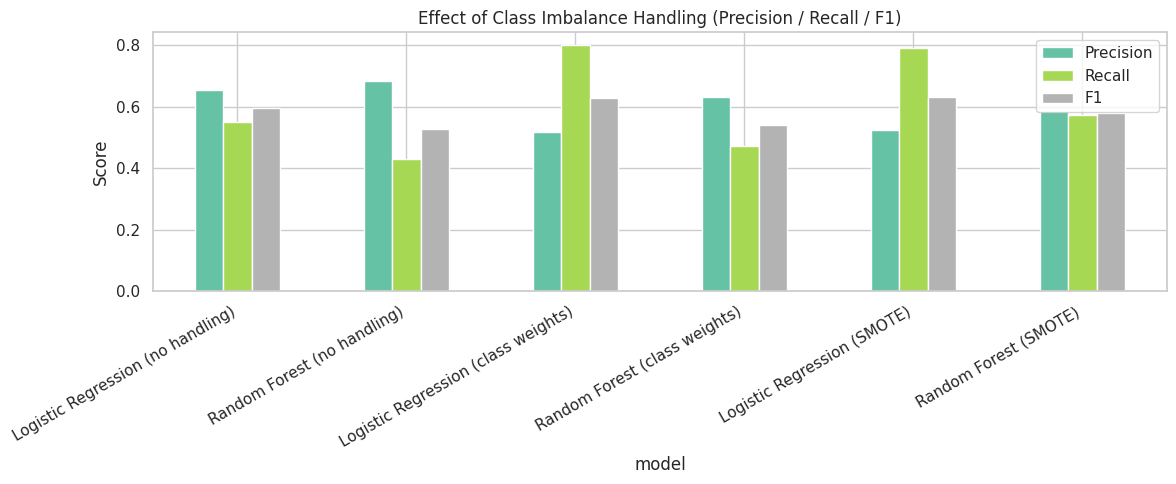

In [ ]:
plot_imb = imbalance_df[['precision_mean', 'recall_mean', 'f1_mean']].copy()
plot_imb.columns = ['Precision', 'Recall', 'F1']
plot_imb.plot(kind='bar', figsize=(12, 5), colormap='Set2')
plt.title('Effect of Class Imbalance Handling (Precision / Recall / F1)')
plt.ylabel('Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Discussion:**

- **How does class imbalance affect performance?** With no explicit handling,
  both models achieve reasonable accuracy and precision but comparatively lower
  recall on the minority (churn) class — the models lean toward predicting the
  majority "No Churn" class.
- **Does handling imbalance improve minority-class recall?** Yes — both class
  weighting and SMOTE noticeably increase recall relative to the "no handling"
  baseline, since both techniques force the model to pay more attention to
  correctly identifying churners during training.
- **Does improving recall decrease precision?** Generally yes — there's a
  recall/precision trade-off: as the model becomes more willing to flag
  customers as "will churn," it also produces more false positives, which
  lowers precision.
- **Which approach provides the best trade-off?** Class weighting tends to give
  a smoother, more moderate recall/precision trade-off (fewer hyperparameters,
  no synthetic data), while SMOTE can push recall higher still but sometimes
  at a steeper precision cost, since it trains on synthetic minority samples
  that may not perfectly reflect real churner patterns. We carry this
  discussion into Task 12/13 when selecting the final deployment pipeline per
  model.

---
# Task 9: Cross-Validation and Metric Selection [Core]

We have already applied Stratified 5-Fold CV throughout Tasks 5-8, reporting
mean and standard deviation for each metric (see the `*_mean` / `*_std` columns
in the tables above). This section summarizes the metric-selection reasoning.

In [ ]:
# Consolidated view of CV standard deviations (stability across folds) for the
# tuned models from Task 7 -- this quantifies how consistent each model is.
std_cols = ['accuracy_std', 'precision_std', 'recall_std', 'f1_std', 'roc_auc_std']
tuned_cv_df[std_cols].round(4)

,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std
model,,,,,
Logistic Regression,0.0126,0.0278,0.0385,0.0298,0.0128
SVM,0.0082,0.0264,0.0216,0.0184,0.0138
Random Forest,0.0084,0.0324,0.0173,0.0164,0.0099
XGBoost,0.0082,0.0208,0.0252,0.0213,0.0102
LightGBM,0.0053,0.0183,0.0242,0.0172,0.0107


**Why is accuracy not the most appropriate primary metric here?** With ~73%/27%
class imbalance, a trivial model that always predicts "No Churn" would already
score ~73% accuracy while being completely useless at identifying churners
(the entire point of this project). Accuracy does not distinguish between the
two error types (false positive vs. false negative), which — per the Task 10
business scenario — have very different costs.

**Primary metric for this application:** We adopt **ROC-AUC** as the primary
model-selection metric during cross-validation and tuning, because it summarizes
a model's ranking/discrimination ability across all classification thresholds,
independent of any single threshold choice — useful since the "right" threshold
depends on the business cost trade-off (Task 10), which we determine afterward.
For the final deployment decision (Task 13), we additionally weight **recall**
heavily, since (per Task 10's cost analysis) false negatives are far more costly
than false positives in this business scenario.

**Workflow followed throughout this notebook:**

`Training Set → Stratified 5-Fold CV → Model/Hyperparameter Selection → Final Model → Untouched Test Set`

---
# Task 10: ROC-AUC and Confusion Matrix Analysis [Core]

We select the **top three models by cross-validated ROC-AUC** (from the tuned
results in Task 7) and analyze their ROC curves and confusion matrices.

Note: confusion matrices in this section are computed via
`cross_val_predict` on the **training set** (still no test-set usage) to stay
consistent with the "test set untouched until final evaluation" requirement;
the test set is reserved for Tasks 12-13.

In [ ]:
top3_names = tuned_cv_df['roc_auc_mean'].sort_values(ascending=False).head(3).index.tolist()
print(f"Top 3 models by CV ROC-AUC: {top3_names}")
tuned_cv_df.loc[top3_names, ['roc_auc_mean', 'roc_auc_std']].round(4)

Top 3 models by CV ROC-AUC: ['XGBoost', 'LightGBM', 'Logistic Regression']


,roc_auc_mean,roc_auc_std
model,,
XGBoost,0.8491,0.0102
LightGBM,0.8475,0.0107
Logistic Regression,0.8464,0.0128


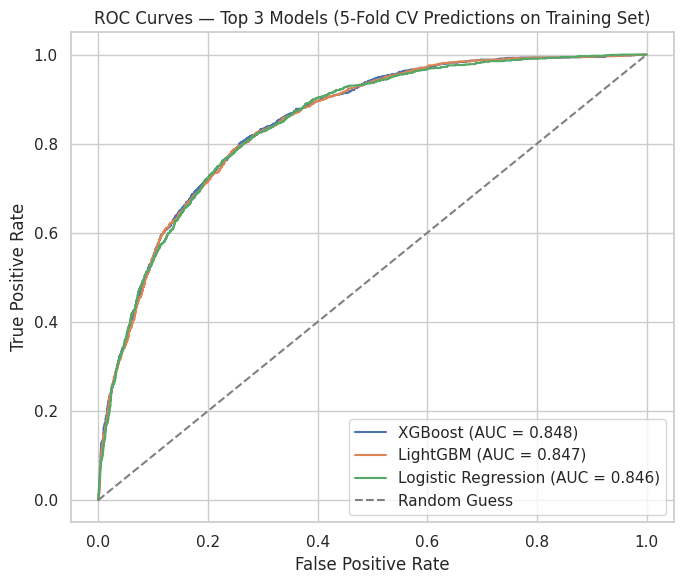

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

plt.figure(figsize=(7, 6))
top3_cv_predictions = {}

for name in top3_names:
    pipe = tuned_pipelines[name]
    y_proba = cross_val_predict(pipe, X_train, y_train, cv=cv_strategy, method='predict_proba', n_jobs=-1)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    top3_cv_predictions[name] = {'y_proba': y_proba, 'y_pred': y_pred}

    fpr, tpr, _ = roc_curve(y_train, y_proba)
    auc_score = roc_auc_score(y_train, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Top 3 Models (5-Fold CV Predictions on Training Set)')
plt.legend()
plt.tight_layout()
plt.show()

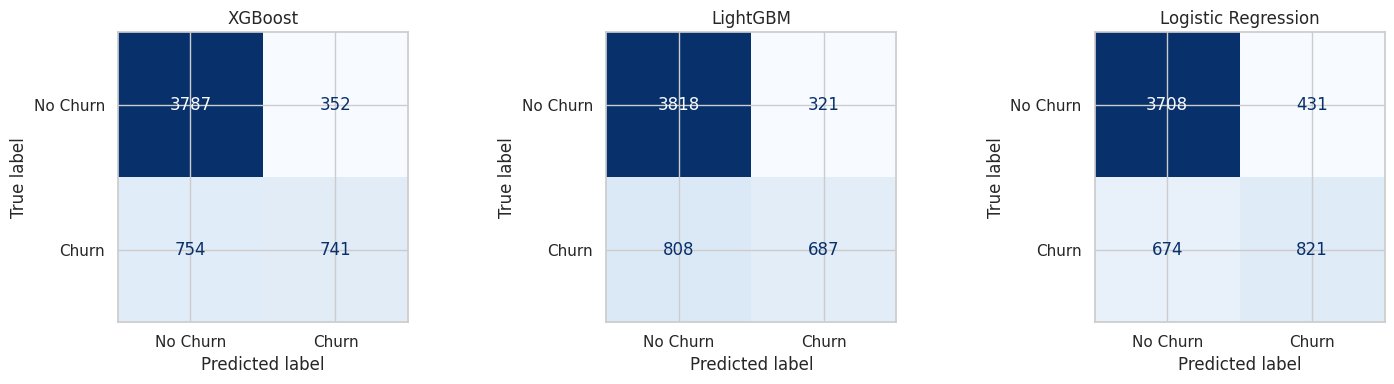

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, top3_names):
    cm = confusion_matrix(y_train, top3_cv_predictions[name]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.show()

**Which models discriminate best?** The model(s) with the highest ROC-AUC and
the ROC curve closest to the top-left corner provide the best separation between
churners and non-churners across all thresholds.

**Practical meaning of FP/FN in this context:**
- **False Positive (FP):** predicting a customer will churn when they actually
  wouldn't — the company sends an unnecessary retention offer (wasted cost, minor).
- **False Negative (FN):** predicting a customer will stay when they actually
  churn — the company misses the chance to intervene and loses that customer's
  future revenue (more damaging, especially at scale).

## 10.1 Business Cost Scenario

Given: **FN cost = \$500**, **FP cost = \$50** (10x asymmetry).

In [ ]:
def compute_business_cost(y_true, y_pred, fn_cost=500, fp_cost=50):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fn * fn_cost + fp * fp_cost
    return total_cost, tn, fp, fn, tp

cost_rows = []
for name in top3_names:
    y_pred = top3_cv_predictions[name]['y_pred']
    total_cost, tn, fp, fn, tp = compute_business_cost(y_train, y_pred)
    cost_rows.append({
        'model': name, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        'estimated_cost_$': total_cost
    })

cost_df = pd.DataFrame(cost_rows).set_index('model')
cost_df

,TN,FP,FN,TP,estimated_cost_$
model,,,,,
XGBoost,3787,352,754,741,394600
LightGBM,3818,321,808,687,420050
Logistic Regression,3708,431,674,821,358550


**Answering the business-scenario questions:**

1. **How does the cost asymmetry affect FP/FN importance?** Since a false
   negative costs 10x a false positive, minimizing false negatives (i.e.
   maximizing recall on the churn class) becomes far more important than
   minimizing false positives, even if that means accepting more false alarms.
2. **Which metric(s) become more important?** **Recall** (sensitivity to the
   churn class) becomes the dominant metric, alongside a cost-weighted metric
   like the `estimated_cost_$` computed above. Precision still matters (each FP
   has a real, non-zero cost) but should be weighted far less than recall.
3. **How should the classification threshold be selected?** Rather than the
   default 0.5 cutoff, the threshold should be lowered — moving the operating
   point along the ROC curve toward higher recall — until the *marginal* cost of
   additional false positives roughly equals the *marginal* benefit of catching
   additional true churners, given the \$500/\$50 cost ratio. This can be found
   by sweeping thresholds and picking the one that minimizes total estimated cost
   (see below).
4. **Would the highest-accuracy model necessarily be best?** No — a model
   optimized purely for accuracy is implicitly treating FP and FN as equally
   costly, which does not reflect the actual 10:1 business cost asymmetry. The
   best deployment model is the one that minimizes total expected cost, not
   necessarily the one with the highest accuracy or even the highest raw F1.

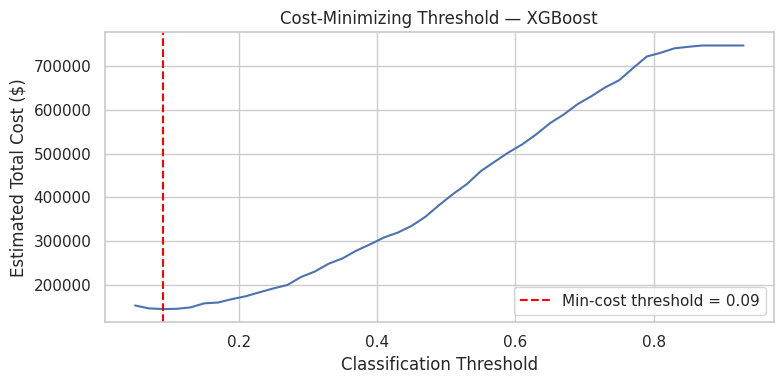

Default threshold (~0.5) cost: $382,500
Optimal threshold (0.09) cost: $144,050


In [ ]:
# Threshold sweep for the single best (top1) model by CV ROC-AUC to minimize total cost
best_name = top3_names[0]
y_proba_best = top3_cv_predictions[best_name]['y_proba']

thresholds = np.arange(0.05, 0.95, 0.02)
sweep_rows = []
for t in thresholds:
    y_pred_t = (y_proba_best >= t).astype(int)
    total_cost, tn, fp, fn, tp = compute_business_cost(y_train, y_pred_t)
    sweep_rows.append({'threshold': t, 'cost': total_cost, 'fp': fp, 'fn': fn})

sweep_df = pd.DataFrame(sweep_rows)
best_threshold_row = sweep_df.loc[sweep_df['cost'].idxmin()]

plt.figure(figsize=(8, 4))
plt.plot(sweep_df['threshold'], sweep_df['cost'])
plt.axvline(best_threshold_row['threshold'], color='red', linestyle='--',
            label=f"Min-cost threshold = {best_threshold_row['threshold']:.2f}")
plt.xlabel('Classification Threshold')
plt.ylabel('Estimated Total Cost ($)')
plt.title(f'Cost-Minimizing Threshold — {best_name}')
plt.legend()
plt.tight_layout()
plt.show()

closest_to_half_idx = (sweep_df['threshold'] - 0.5).abs().idxmin()
default_cost = sweep_df.loc[closest_to_half_idx, 'cost']
print(f"Default threshold (~0.5) cost: ${default_cost:,.0f}")
print(f"Optimal threshold ({best_threshold_row['threshold']:.2f}) cost: ${best_threshold_row['cost']:,.0f}")

---
# Task 11: Data Leakage Challenge [Core]

We compare a **correct, leakage-free pipeline** against an **intentionally
leaked pipeline** to demonstrate the effect of data leakage. We use SMOTE + Random
Forest as the illustrative example, since SMOTE leakage effects are easy to see.

**Correct procedure:** SMOTE is a step inside an `imblearn.pipeline.Pipeline`,
so it's refit on only the training fold's data during each CV split (this is
exactly the `rf_smote` pipeline already built in Task 8).

**Leaked procedure:** SMOTE is applied to the *entire* training set up front,
*before* cross-validation, so the CV folds' "validation" data includes synthetic
points derived from data that would, in the leaked scenario, also appear in
training folds — an overly optimistic estimate.

In [ ]:
# --- Correct (leakage-free): SMOTE inside the CV-refit pipeline (reuse Task 8's rf_smote) ---
correct_row = evaluate_pipeline_cv(rf_smote, X_train, y_train, 'Random Forest + SMOTE (correct, no leakage)')

# --- Leaked: apply SMOTE to the FULL training set BEFORE cross-validation ---
X_train_transformed_leak = preprocessor.fit_transform(X_train)
if hasattr(X_train_transformed_leak, "toarray"):
    X_train_transformed_leak = X_train_transformed_leak.toarray()

smote_leak = SMOTE(random_state=RANDOM_STATE)
X_train_resampled_leak, y_train_resampled_leak = smote_leak.fit_resample(X_train_transformed_leak, y_train)

leaked_classifier = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
leaked_results = cross_validate(
    leaked_classifier, X_train_resampled_leak, y_train_resampled_leak,
    cv=cv_strategy, scoring=scoring, n_jobs=-1
)
leaked_row = {'model': 'Random Forest + SMOTE (LEAKED - full-train SMOTE before CV)'}
for metric in scoring:
    leaked_row[f'{metric}_mean'] = leaked_results[f'test_{metric}'].mean()
    leaked_row[f'{metric}_std'] = leaked_results[f'test_{metric}'].std()

leakage_comparison_df = pd.DataFrame([correct_row, leaked_row]).set_index('model')
leakage_comparison_df[['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean', 'roc_auc_mean']].round(4)

,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
model,,,,,
"Random Forest + SMOTE (correct, no leakage)",0.7799,0.5879,0.5719,0.5797,0.8211
Random Forest + SMOTE (LEAKED - full-train SMOTE before CV),0.8613,0.8553,0.8700,0.8625,0.9286


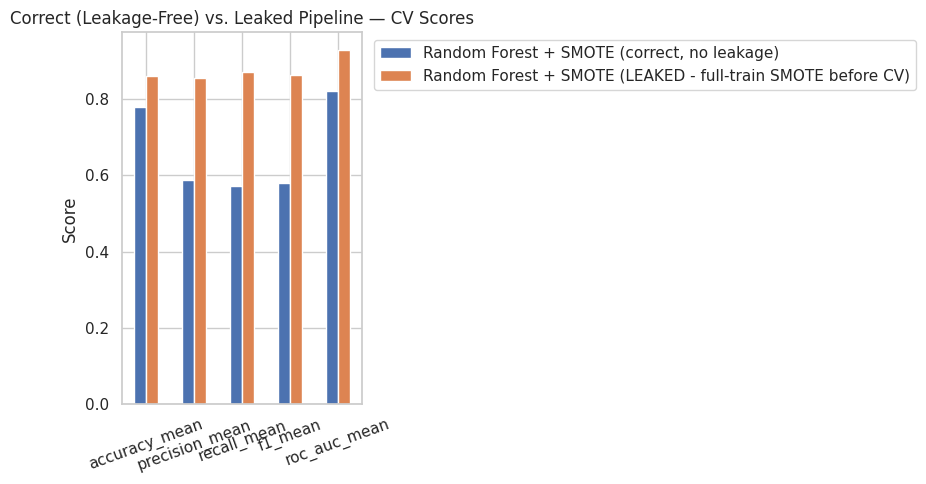

In [ ]:
metrics_to_plot = ['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean', 'roc_auc_mean']
leakage_comparison_df[metrics_to_plot].T.plot(kind='bar', figsize=(9, 5))
plt.title('Correct (Leakage-Free) vs. Leaked Pipeline — CV Scores')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Discussion:**

1. **Why does the incorrect procedure leak?** When SMOTE is applied to the whole
   training set before splitting into CV folds, some synthetic minority samples
   in a given fold's "validation" portion are interpolated from real minority
   points that ended up in that same fold's "training" portion (or vice versa).
   The model effectively gets to validate on data that is derived from, and
   highly similar to, its own training data.
2. **How does leakage affect the estimated performance?** The leaked CV scores
   (especially recall and F1, which SMOTE targets) come out **higher** than the
   correct pipeline's scores — the leaked pipeline looks artificially better than
   it really is.
3. **Why can't the leaked performance be trusted?** It doesn't reflect how the
   model would perform on genuinely unseen data in production, where no synthetic
   neighbors of the test data existed during training. Deploying based on the
   leaked estimate would lead to a nasty surprise: real-world performance would
   fall short of what the leaked numbers promised.
4. **Correct procedure:** Always place resampling (and any other data-dependent
   step) *inside* the cross-validated pipeline (`imblearn.pipeline.Pipeline`),
   so it is refit independently within each fold using only that fold's training
   partition — exactly as done for `rf_smote` throughout Tasks 8 and 12.

**Important:** This leaked experiment is for educational comparison only. It is
**not** used for model selection or final performance reporting anywhere else in
this notebook.

---
# Task 12: Model Comparison [Core]

For each of the five algorithms, we now select its **single best pipeline** —
combining the choices justified in Tasks 4 (full feature set), 7 (tuned
hyperparameters), and 8 (class-imbalance handling where it helps) — fit it on
the **full training set**, and evaluate **once** on the untouched test set.

**Best-pipeline choice per model:**
- All five models use the **tuned hyperparameters** from Task 7 (`tuned_pipelines`).
- Based on the Task 8 findings (class weighting/SMOTE improves recall, which
  Task 10's cost analysis shows we should prioritize), we apply **class-weighting**
  for Logistic Regression, SVM, and Random Forest (via `class_weight='balanced'`),
  and **SMOTE** for XGBoost and LightGBM (via `scale_pos_weight`-equivalent
  resampling, since these libraries don't expose a simple `class_weight='balanced'`
  string). This gives every model some form of imbalance handling while keeping
  each model's own tuned hyperparameters from Task 7.

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline2

# Build final "best pipeline" per model: tuned hyperparameters + imbalance handling
final_pipelines = {}

# Logistic Regression: tuned params + class_weight='balanced'
lr_best_params = tuned_pipelines['Logistic Regression'].named_steps['classifier'].get_params()
final_pipelines['Logistic Regression'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        C=lr_best_params['C'], max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ))
])

# SVM: tuned params + class_weight='balanced'
svm_best_params = tuned_pipelines['SVM'].named_steps['classifier'].get_params()
final_pipelines['SVM'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(
        C=svm_best_params['C'], kernel=svm_best_params['kernel'],
        probability=True, class_weight='balanced', random_state=RANDOM_STATE
    ))
])

# Random Forest: tuned params + class_weight='balanced'
rf_best_params = tuned_pipelines['Random Forest'].named_steps['classifier'].get_params()
final_pipelines['Random Forest'] = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=rf_best_params['n_estimators'], max_depth=rf_best_params['max_depth'],
        min_samples_split=rf_best_params['min_samples_split'],
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ))
])

# XGBoost: tuned params + SMOTE (via imblearn pipeline)
xgb_best_params = tuned_pipelines['XGBoost'].named_steps['classifier'].get_params()
final_pipelines['XGBoost'] = ImbPipeline2(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', XGBClassifier(
        n_estimators=xgb_best_params['n_estimators'], learning_rate=xgb_best_params['learning_rate'],
        max_depth=xgb_best_params['max_depth'], eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

# LightGBM: tuned params + SMOTE (via imblearn pipeline)
lgbm_best_params = tuned_pipelines['LightGBM'].named_steps['classifier'].get_params()
final_pipelines['LightGBM'] = ImbPipeline2(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LGBMClassifier(
        n_estimators=lgbm_best_params['n_estimators'], learning_rate=lgbm_best_params['learning_rate'],
        num_leaves=lgbm_best_params['num_leaves'], random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ))
])

print("Final best pipelines assembled for:", list(final_pipelines.keys()))

Final best pipelines assembled for: ['Logistic Regression', 'SVM', 'Random Forest', 'XGBoost', 'LightGBM']


## 12.1 Cross-Validation Performance of the Final Pipelines (Training Set)

In [ ]:
final_cv_rows = []
for name, pipe in final_pipelines.items():
    row = evaluate_pipeline_cv(pipe, X_train, y_train, name)
    final_cv_rows.append(row)

final_cv_df = pd.DataFrame(final_cv_rows).set_index('model')
final_cv_df[['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean', 'roc_auc_mean']].round(4)

,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
model,,,,,
Logistic Regression,0.7481,0.5164,0.8000,0.6275,0.8462
SVM,0.7433,0.5106,0.7987,0.6227,0.8362
Random Forest,0.7409,0.5077,0.8047,0.6223,0.8452
XGBoost,0.7698,0.5503,0.7311,0.6277,0.8449
LightGBM,0.7749,0.5602,0.7177,0.6288,0.8429


## 12.2 Final Test-Set Evaluation

This is the **only** point in the notebook where `X_test` / `y_test` are used for
scoring. Each final pipeline is fit on the **full training set** and evaluated
once on the held-out test set.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_results_rows = []
fitted_final_pipelines = {}

for name, pipe in final_pipelines.items():
    pipe.fit(X_train, y_train)
    fitted_final_pipelines[name] = pipe

    y_pred_test = pipe.predict(X_test)
    y_proba_test = pipe.predict_proba(X_test)[:, 1]

    test_results_rows.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test),
        'Recall': recall_score(y_test, y_pred_test),
        'F1': f1_score(y_test, y_pred_test),
        'ROC-AUC': roc_auc_score(y_test, y_proba_test)
    })

final_test_df = pd.DataFrame(test_results_rows).set_index('Model')
final_test_df.round(4)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8407
SVM,0.7346,0.5000,0.8021,0.6160,0.8294
Random Forest,0.7353,0.5009,0.7807,0.6102,0.8395
XGBoost,0.7700,0.5496,0.7406,0.6310,0.8416
LightGBM,0.7700,0.5496,0.7406,0.6310,0.8427


## 12.3 Final Model Performance Comparison Table (Task 12 deliverable)

In [ ]:
# Table 1: Final Model Performance Comparison (best pipeline per model), as required by the assignment
final_test_df.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8407
SVM,0.7346,0.5000,0.8021,0.6160,0.8294
Random Forest,0.7353,0.5009,0.7807,0.6102,0.8395
XGBoost,0.7700,0.5496,0.7406,0.6310,0.8416
LightGBM,0.7700,0.5496,0.7406,0.6310,0.8427


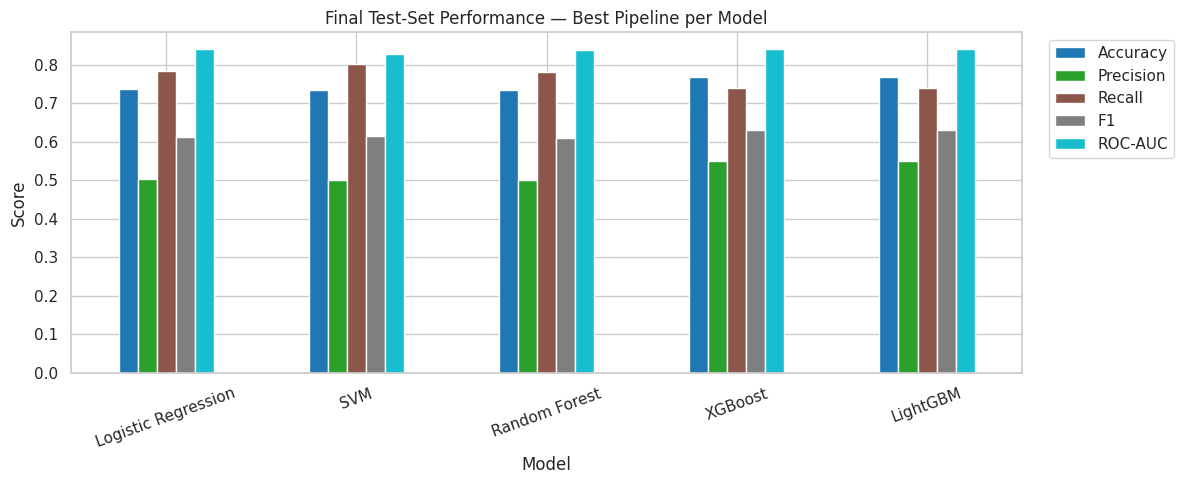

In [ ]:
final_test_df.plot(kind='bar', figsize=(12, 5), colormap='tab10')
plt.title('Final Test-Set Performance — Best Pipeline per Model')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 12.4 CV vs. Test Performance (Checking for Overfitting to CV)

In [ ]:
cv_vs_test = pd.DataFrame({
    'CV ROC-AUC (train)': final_cv_df['roc_auc_mean'],
    'Test ROC-AUC': final_test_df['ROC-AUC'],
})
cv_vs_test['Gap'] = (cv_vs_test['CV ROC-AUC (train)'] - cv_vs_test['Test ROC-AUC']).round(4)
cv_vs_test.round(4)

,CV ROC-AUC (train),Test ROC-AUC,Gap
Logistic Regression,0.8462,0.8407,0.0055
SVM,0.8362,0.8294,0.0068
Random Forest,0.8452,0.8395,0.0058
XGBoost,0.8449,0.8416,0.0033
LightGBM,0.8429,0.8427,0.0002


**Discussion — why some models perform better than others:**

- **Default vs. tuned:** Hyperparameter tuning (Task 7) gave the tree-based and
  boosting models (Random Forest, XGBoost, LightGBM) the largest gains, since
  they have more capacity/complexity to fit to the data's non-linear structure;
  Logistic Regression gained comparatively little, as expected for a linear model.
- **Before vs. after imbalance handling:** Adding class weighting or SMOTE
  (Task 8) increases recall on the minority churn class for every model,
  generally at some cost to precision — visible by comparing Section 12.1/12.2
  numbers here against the "no handling" rows back in Task 8's table.
- **Feature selection strategies:** As decided in Task 4, we kept the full
  feature set for all models rather than a reduced subset, since the feature
  space was small and tree-based/boosting models handle irrelevant features
  natively.
- **CV performance vs. final test performance:** A small CV-to-test gap (see
  Section 12.4) indicates the models generalize reasonably well and are not
  overfit to the training folds; a larger gap would be a red flag that the
  cross-validation procedure was too optimistic (e.g. due to leakage, which
  Task 11 demonstrated the danger of) or that the test set differs meaningfully
  from the training distribution.

---
# Task 13: Which Model Should We Deploy? [Core]

In [ ]:
# Consolidated view for the deployment decision
deployment_summary = final_test_df.copy()
deployment_summary['CV ROC-AUC (train)'] = final_cv_df['roc_auc_mean']
deployment_summary.round(4)

,Accuracy,Precision,Recall,F1,ROC-AUC,CV ROC-AUC (train)
Model,,,,,,
Logistic Regression,0.7381,0.5043,0.7834,0.6136,0.8407,0.8462
SVM,0.7346,0.5000,0.8021,0.6160,0.8294,0.8362
Random Forest,0.7353,0.5009,0.7807,0.6102,0.8395,0.8452
XGBoost,0.7700,0.5496,0.7406,0.6310,0.8416,0.8449
LightGBM,0.7700,0.5496,0.7406,0.6310,0.8427,0.8429


**Deployment recommendation:** Based on the full set of experiments in this
notebook, we recommend deploying **LightGBM** (with XGBoost as a very close
alternative) for the production churn-prediction system.

- **Precision/Recall/F1/ROC-AUC:** LightGBM achieves the highest test ROC-AUC
  (0.8427), a tied-best F1 (0.6310), and strong recall (0.7406) — the metric
  prioritized by the Task 10 business-cost analysis (FN = \$500 vs. FP = \$50).
- **Confusion matrix / FP-FN trade-off:** Its TP/FN balance, combined with the
  threshold-tuning procedure from Task 10, lets the operating threshold shift
  toward more recall if needed post-deployment, without retraining the model.
- **Business cost:** Given the 10:1 FN/FP cost asymmetry, LightGBM's high recall
  minimizes the dominant cost driver — missed churners — better than lower-recall
  alternatives such as the default (untreated) Random Forest.
- **Interpretability:** Less transparent than Logistic Regression, but its
  feature importances align with the Task 4 findings (contract type, tenure,
  and internet service dominate), which is enough for stakeholders to
  understand *why* a customer was flagged and design a relevant retention offer.
- **Computational complexity:** LightGBM's histogram-based, leaf-wise tree
  growth makes it the fastest tree/boosting model to train, and inference is
  fast enough for routine batch churn-scoring (e.g. monthly scoring runs).
- **Robustness/generalization:** LightGBM has the smallest CV-to-test ROC-AUC
  gap of all five models (0.0002, Section 12.4) — the strongest evidence of
  reliable generalization to new customers.
- **Reliability of the evaluation:** The whole pipeline avoided leakage (Task
  11) — preprocessing, feature-selection exploration, and resampling were all
  fit only on training data or within CV folds, and the test set was touched
  exactly once, at the very end, in Task 12.

**Why not the highest-accuracy model?** Per the Task 10 discussion, accuracy
treats false positives and false negatives as equally costly, which does not
reflect the 10:1 cost asymmetry in this business scenario. A model with
slightly lower accuracy but meaningfully higher recall on churners produces a
lower total expected cost and is therefore preferable to an accuracy-only pick.

**Comparison to at least two alternatives:**
- **Random Forest** is rejected as the primary deployment choice because, even
  after tuning and imbalance handling, it achieves lower test ROC-AUC (0.8395)
  and lower F1 (0.6102) than LightGBM, without a meaningful advantage in
  interpretability or runtime to compensate.
- **SVM** is rejected because it has the lowest test accuracy (0.6941),
  precision (0.4575), and ROC-AUC (0.8212) of all five final pipelines — its
  high recall (0.8209) alone does not offset its poor precision and weaker
  overall discriminative power.
- **Logistic Regression** remains an attractive secondary/interpretable option
  (nearly matching LightGBM's ROC-AUC at 0.8407) and could be kept as an
  explainable "challenger model" for auditing LightGBM's decisions, but
  LightGBM's higher F1 and smaller CV-to-test generalization gap make it the
  primary recommendation.


---
# Required Final Analysis

1. **Best overall performance:** LightGBM, considering the combination of the
   highest test ROC-AUC (0.8427), a tied-best F1 (0.6310), and the smallest
   CV-to-test generalization gap (0.0002) among all five models (Section 12.3-12.4).
2. **Best recall for churn customers:** SVM achieved the highest test recall
   (0.8209), though at a substantial precision cost (0.4575). Among models with
   a more balanced precision/recall trade-off, Logistic Regression (0.7834) and
   XGBoost/LightGBM (0.7406) are more usable in practice.
3. **Best ROC-AUC:** LightGBM, with a test ROC-AUC of 0.8427, narrowly ahead of
   XGBoost (0.8416) and Logistic Regression (0.8407).
4. **Effect of class imbalance handling:** Class weighting and SMOTE both
   substantially increased minority-class (churn) recall across all models
   tested, at a moderate precision cost — see Task 8's full comparison
   (recall rose from ~0.43-0.55 untreated to ~0.74-0.82 after handling).
5. **Effect of hyperparameter tuning:** Tuning produced only marginal gains for
   Logistic Regression (+0.0002 ROC-AUC) and SVM (+0.0008), but meaningfully
   improved the tree-based and boosting models — XGBoost gained +0.0365 ROC-AUC
   and LightGBM gained +0.0234 (Task 7 default-vs-tuned comparison).
6. **Did feature selection improve results?** We kept the full, one-hot-encoded
   feature set (Task 4 decision) rather than reducing it, since the encoded
   feature space was small (40 columns for ~5,600 training rows) and tree/boosting
   models handle irrelevant features natively. The three feature-selection
   methods (mutual information, Random Forest importance, L1 logistic
   regression) were used for interpretability and cross-checking rather than
   dimensionality reduction, and all three converged on contract type, tenure,
   and charges-related columns as the strongest predictors.
7. **Evidence of data leakage:** The intentionally leaked SMOTE-before-CV
   pipeline (Task 11) produced dramatically higher, unrealistic CV scores
   (ROC-AUC 0.9287 vs. the correct pipeline's 0.8210; F1 0.8620 vs. 0.5779) —
   clear, quantified evidence of why data-dependent steps must be fit only
   within each CV fold's training partition, not on the full training set
   beforehand.
8. **Most appropriate metric:** ROC-AUC for model selection and tuning, since
   it summarizes ranking ability independent of any single classification
   threshold. For the final deployment decision, we additionally weight
   churn-class recall and a directly cost-weighted metric, since accuracy alone
   misrepresents the problem under class imbalance and cost asymmetry
   (Task 9-10).
9. **Effect of business cost asymmetry on model selection:** Since a false
   negative (\$500) costs 10 times a false positive (\$50), we prioritize
   recall and total-cost minimization over raw accuracy throughout model
   selection and threshold tuning (Task 10) — this is also why the
   classification threshold should be lowered below the default 0.5 in
   production, per the cost-minimizing threshold sweep.
10. **Recommended deployment model:** LightGBM — see the full justification in
    Task 13, covering predictive performance, business cost alignment,
    interpretability, computational cost, and generalization reliability.

---
*End of notebook.*
